In [61]:
import matplotlib, numpy, pandas, scipy, shapely, networkx, astropy, aplpy, lmfit

print("matplotlib", matplotlib.__version__ , '3.10.1')
print("numpy", numpy.__version__, '2.2.5')
print("pandas", pandas.__version__, '2.2.3')
print("scipy", scipy.__version__, '1.15.2')
print("shapely", shapely.__version__, '2.1.0')
print("networkx", networkx.__version__, '3.4.2')
print("astropy", astropy.__version__, '7.0.1')
print("aplpy", aplpy.__version__, '2.2.0')
print("lmfit", lmfit.__version__, '1.3.3')

from analysis import analyse, load, plotter
from analysis import polygons_utility as putility
from analysis import network_utility as utility


import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.dpi'] = 150 

matplotlib 3.10.1 3.10.1
numpy 2.2.5 2.2.5
pandas 2.2.3 2.2.3
scipy 1.15.2 1.15.2
shapely 2.1.0 2.1.0
networkx 3.4.2 3.4.2
astropy 7.0.1 7.0.1
aplpy 2.2.0 2.2.0
lmfit 1.3.3 1.3.3
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from pathlib import Path
import pandas as pd

path = Path("./benchmark/config_w43/").resolve()

#reader = lambda x: pd.read_csv(x, **dict(skip_blank_lines=True, header=112,skiprows=[113,114], engine='python', sep="!|\s+"))

def reader(x):
    data = pd.read_csv(x, **dict(skip_blank_lines=True, 
                                 header=112, # index of the header (column names)
                                 skiprows=[113,114], # index of the line(s) to skip after the header until the data
                                 engine='python', 
                                 sep="!|\\s+"))
    step = np.sum(np.isnan(np.array(data.iloc[-1] , dtype=np.float64)))
    data = data.shift(periods= step, axis="columns")
    data = data.drop(data.columns[:step], axis=1)
    return data

dataset = analyse.DataSet(
    analyse.Data(config, reader_to_df=reader)
    for config in path.glob("*.toml")
)

for name, data in dataset.items():
    print(f"sample {name} : {len(data.df)} elements")
    
print(f"total #elements = {sum(data.df.size for data in dataset)}")

sample 270AU : 57 elements
sample 14000AU : 3 elements
sample 650AU : 71 elements
sample 8000AU : 13 elements
sample 2400AU : 48 elements
total #elements = 5760


# Attributes of Data class

- 'path': path of the config file that is used to read the data
- 'df': normalised dataframe the code reads
- 'comment': any comment in the config file
- 'catalog': origin of catalog file
- 'fits_img': fits image from which the objects are extracted
- 'beam': observation beam (in arcsec)
- 'wavelength': wavelenght of observation (in µm)
- 'distance': distance of the region (in pc)
- 'fov_window': polygon object that define the field of view of extraction (-1 if all image is used)
- 'color': color used to represent the data in the figures

In [63]:
network = analyse.Network(dataset, min_overlap=0.75) # create network with a minimum overlap of 0.75

clumps = utility.toDataFrame(network.network) # convert network to dataframe

network.extractStructures() # extract structures from the network
structure_table = network.getStructuresTable() # get the table of extracted structures

In [64]:

clumps

,_Fractality,bsize3mmBsens,scale3mmBsens,s2,asize3mmBsens,fxt_al3mmBsens,fm3mmBsens,_Kind,sx,_R,...,fg,sign,_Holes,s1,foob3mmBsens,yco_p,_Y,fxp_err3mmBsens,_Theta,_Polygon
0,None,0.09128,0.050,79,0.13220,0.007943,0,NodeKind.SINK,25,0.069595,...,1,45.160,0,11,0.3662,1487.3,-1.908148,0.000030,-0.790635,POLYGON ((281.945170187867 -1.9081634467307316...
1,None,0.06450,0.050,79,0.07650,0.002607,0,NodeKind.SINK,25,0.058455,...,0,26.580,0,15,0.1764,1453.4,-1.908233,0.000025,0.577354,POLYGON ((281.9453761249831 -1.908223177957038...
2,None,0.05266,0.050,79,0.06967,0.001263,0,NodeKind.SINK,21,0.052516,...,0,19.210,0,17,0.1500,1045.1,-1.909254,0.000020,0.163188,POLYGON ((281.942707104892 -1.9092508495085438...
3,None,0.05620,0.050,79,0.07166,0.001548,0,NodeKind.SINK,21,0.054749,...,0,19.990,0,17,0.1500,1448.0,-1.908246,0.000025,0.450294,POLYGON ((281.94569519839763 -1.90823866608186...
4,None,0.03613,0.050,79,0.05764,0.001470,0,NodeKind.SINK,21,0.042467,...,1,38.190,0,11,0.1155,1802.8,-1.907360,0.000061,0.346971,POLYGON ((281.9457357700921 -1.907354303780525...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,[1.4847716377667244],1.44800,1.450,61,1.70800,0.001842,10,NodeKind.SOURCE,29,1.695755,...,0,7.391,0,28,3.3510,77.5,-1.912551,0.000572,0.273493,POLYGON ((281.9371218347265 -1.912413569879398...
188,[0.9999999999999999],0.25000,1.450,61,0.25000,0.001231,1,NodeKind.SOURCE,29,1.245375,...,0,7.541,0,27,3.3510,110.4,-1.910265,0.000353,0.027401,POLYGON ((281.93917817996964 -1.91025191477877...
189,[1.6857797153787726],3.04700,3.128,62,3.88900,0.070700,0,NodeKind.SOURCE,36,2.586849,...,1,164.600,0,2,10.9600,152.0,-1.907378,0.002903,-1.160645,POLYGON ((281.9461936491777 -1.908091556528322...
190,[1.6448850212235335],2.77900,3.128,62,3.30800,0.045840,0,NodeKind.SOURCE,36,2.693365,...,1,85.700,0,6,9.2820,140.0,-1.908211,0.002208,-1.378811,POLYGON ((281.94544773470744 -1.90900868980981...


### Structure table

The structure table get different informations from each structure:

- ``component``   : the subgraph of ``network`` for this structure.
- ``sinks``       : total number of sink nodes (finest-scale, leaf sources).
- ``sources``     : total number of source nodes (coarsest-scale, root sources).
- ``productivity``: list of mean number of children per source node at each level
                    (see :func:`productivityPerSource`).
- ``nl``          : total number of nodes per resolution level.
- ``sourcel``     : number of source nodes per level.
- ``sinkl``       : number of sink nodes per level.
- ``mode``        : fragmentation mode (:class:`StructureMode`).
- ``fractality``  : mean fractality index F = mean productivity over source nodes.
- ``missed``      : estimated number of undetected (missing) fragments inferred
                    from holes in sink/intermediate nodes.
- ``percmissed``  : fraction of missing fragments relative to total node count.
- ``triplets``    : number of transitive triplets in the component graph,
                    a measure of tree-like topology.
- ``maxR``        : largest angular resolution (beam size) present in this structure.
- ``YSO``         : number of sink/intermediate nodes associated with a known
                    Young Stellar Object (YSO) classification.
- ``gas``         : number of sink/intermediate nodes with no YSO classification
                    (pure gas condensations).
- ``nbunch``      : list of node identifiers in the component.
- ``polygon``     : :class:`shapely.geometry.Polygon` enclosing the full structure
                    (union of all source polygons).
- ``size``        : characteristic spatial size of the structure in arcsec
                    (square root of polygon area; multiply by distance in kAU/arcsec
                    to convert to kAU).
- ``position``    : (x, y) sky coordinates of the polygon centroid.


In [65]:
structure_table

,component,sinks,sources,mode,fractality,missed,percmissed,maxR,YSO,gas,polygon,size,xposition,yposition
0,"(0, 1, 130, 128, 132, 3, 4, 135, 10, 140, 12, ...",38,4,HIERARCHICAL,1.486735,19.0,0.206522,2.61,0,31,POLYGON ((281.94498267929447 -1.90898792191367...,0.001852,281.945486,-1.907915
1,"(2, 67, 36, 133, 73, 139, 78, 15, 80, 19, 180,...",5,1,HIERARCHICAL,1.450508,0.0,0.000000,1.45,0,7,POLYGON ((281.9429400159765 -1.909295860306181...,0.000743,281.942366,-1.909261
2,"(129, 5, 106, 75, 109, 45, 178, 51, 22, 60, 62)",5,1,HIERARCHICAL,1.385156,1.0,0.083333,1.45,0,5,POLYGON ((281.9436904589437 -1.909230049793830...,0.000700,281.943208,-1.909270
3,"(64, 38, 71, 134, 6, 11, 108, 142, 179, 54, 56...",5,1,HIERARCHICAL,1.326350,2.0,0.133333,2.61,0,7,POLYGON ((281.9446918738635 -1.906564192592714...,0.001305,281.943924,-1.906437
4,"(137, 186, 69, 7)",1,1,LINEAR,1.000000,0.0,0.000000,1.45,0,2,POLYGON ((281.93702385797803 -1.91040495206657...,0.000606,281.936596,-1.910514
5,"(8, 65, 145)",1,1,LINEAR,1.000000,0.0,0.000000,0.43,0,1,POLYGON ((281.94618834880185 -1.90896691369646...,0.000188,281.946060,-1.908932
6,"(9, 141, 81, 18, 84, 181, 148, 88, 90, 124, 31)",5,1,HIERARCHICAL,1.385156,1.0,0.083333,1.45,0,5,POLYGON ((281.9445688356894 -1.908856980065423...,0.000881,281.943938,-1.908940
7,"(99, 74, 138, 17, 50, 184)",2,1,HIERARCHICAL,1.154328,1.0,0.142857,1.45,0,3,POLYGON ((281.94532818424824 -1.90427730601443...,0.000606,281.945003,-1.904473
8,"(131, 44, 79, 20, 182, 58)",2,1,HIERARCHICAL,1.154328,0.0,0.000000,1.45,0,3,POLYGON ((281.9474312760199 -1.908274672570955...,0.000606,281.946995,-1.908246
9,"(160, 25, 83)",1,1,LINEAR,1.000000,0.0,0.000000,0.43,0,1,POLYGON ((281.945555769206 -1.9067983570406104...,0.000201,281.945419,-1.906744


In [66]:
suspicious = np.array([]) # used to flag suspicious structures


hierarchical_structures = structure_table.loc[structure_table["mode"] == "HIERARCHICAL", "component"]


#hierarchical_structures[~hierarchical_structures.index.isin(suspicious)]
#to_consider = structure_table[~structure_table.index.isin(suspicious)]
to_consider = structure_table
to_consider.index = np.arange(0, len(to_consider))

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


INFO: Auto-setting vmin to -4.716e-04 [aplpy.core]
INFO: Auto-setting vmax to  5.794e-04 [aplpy.core]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


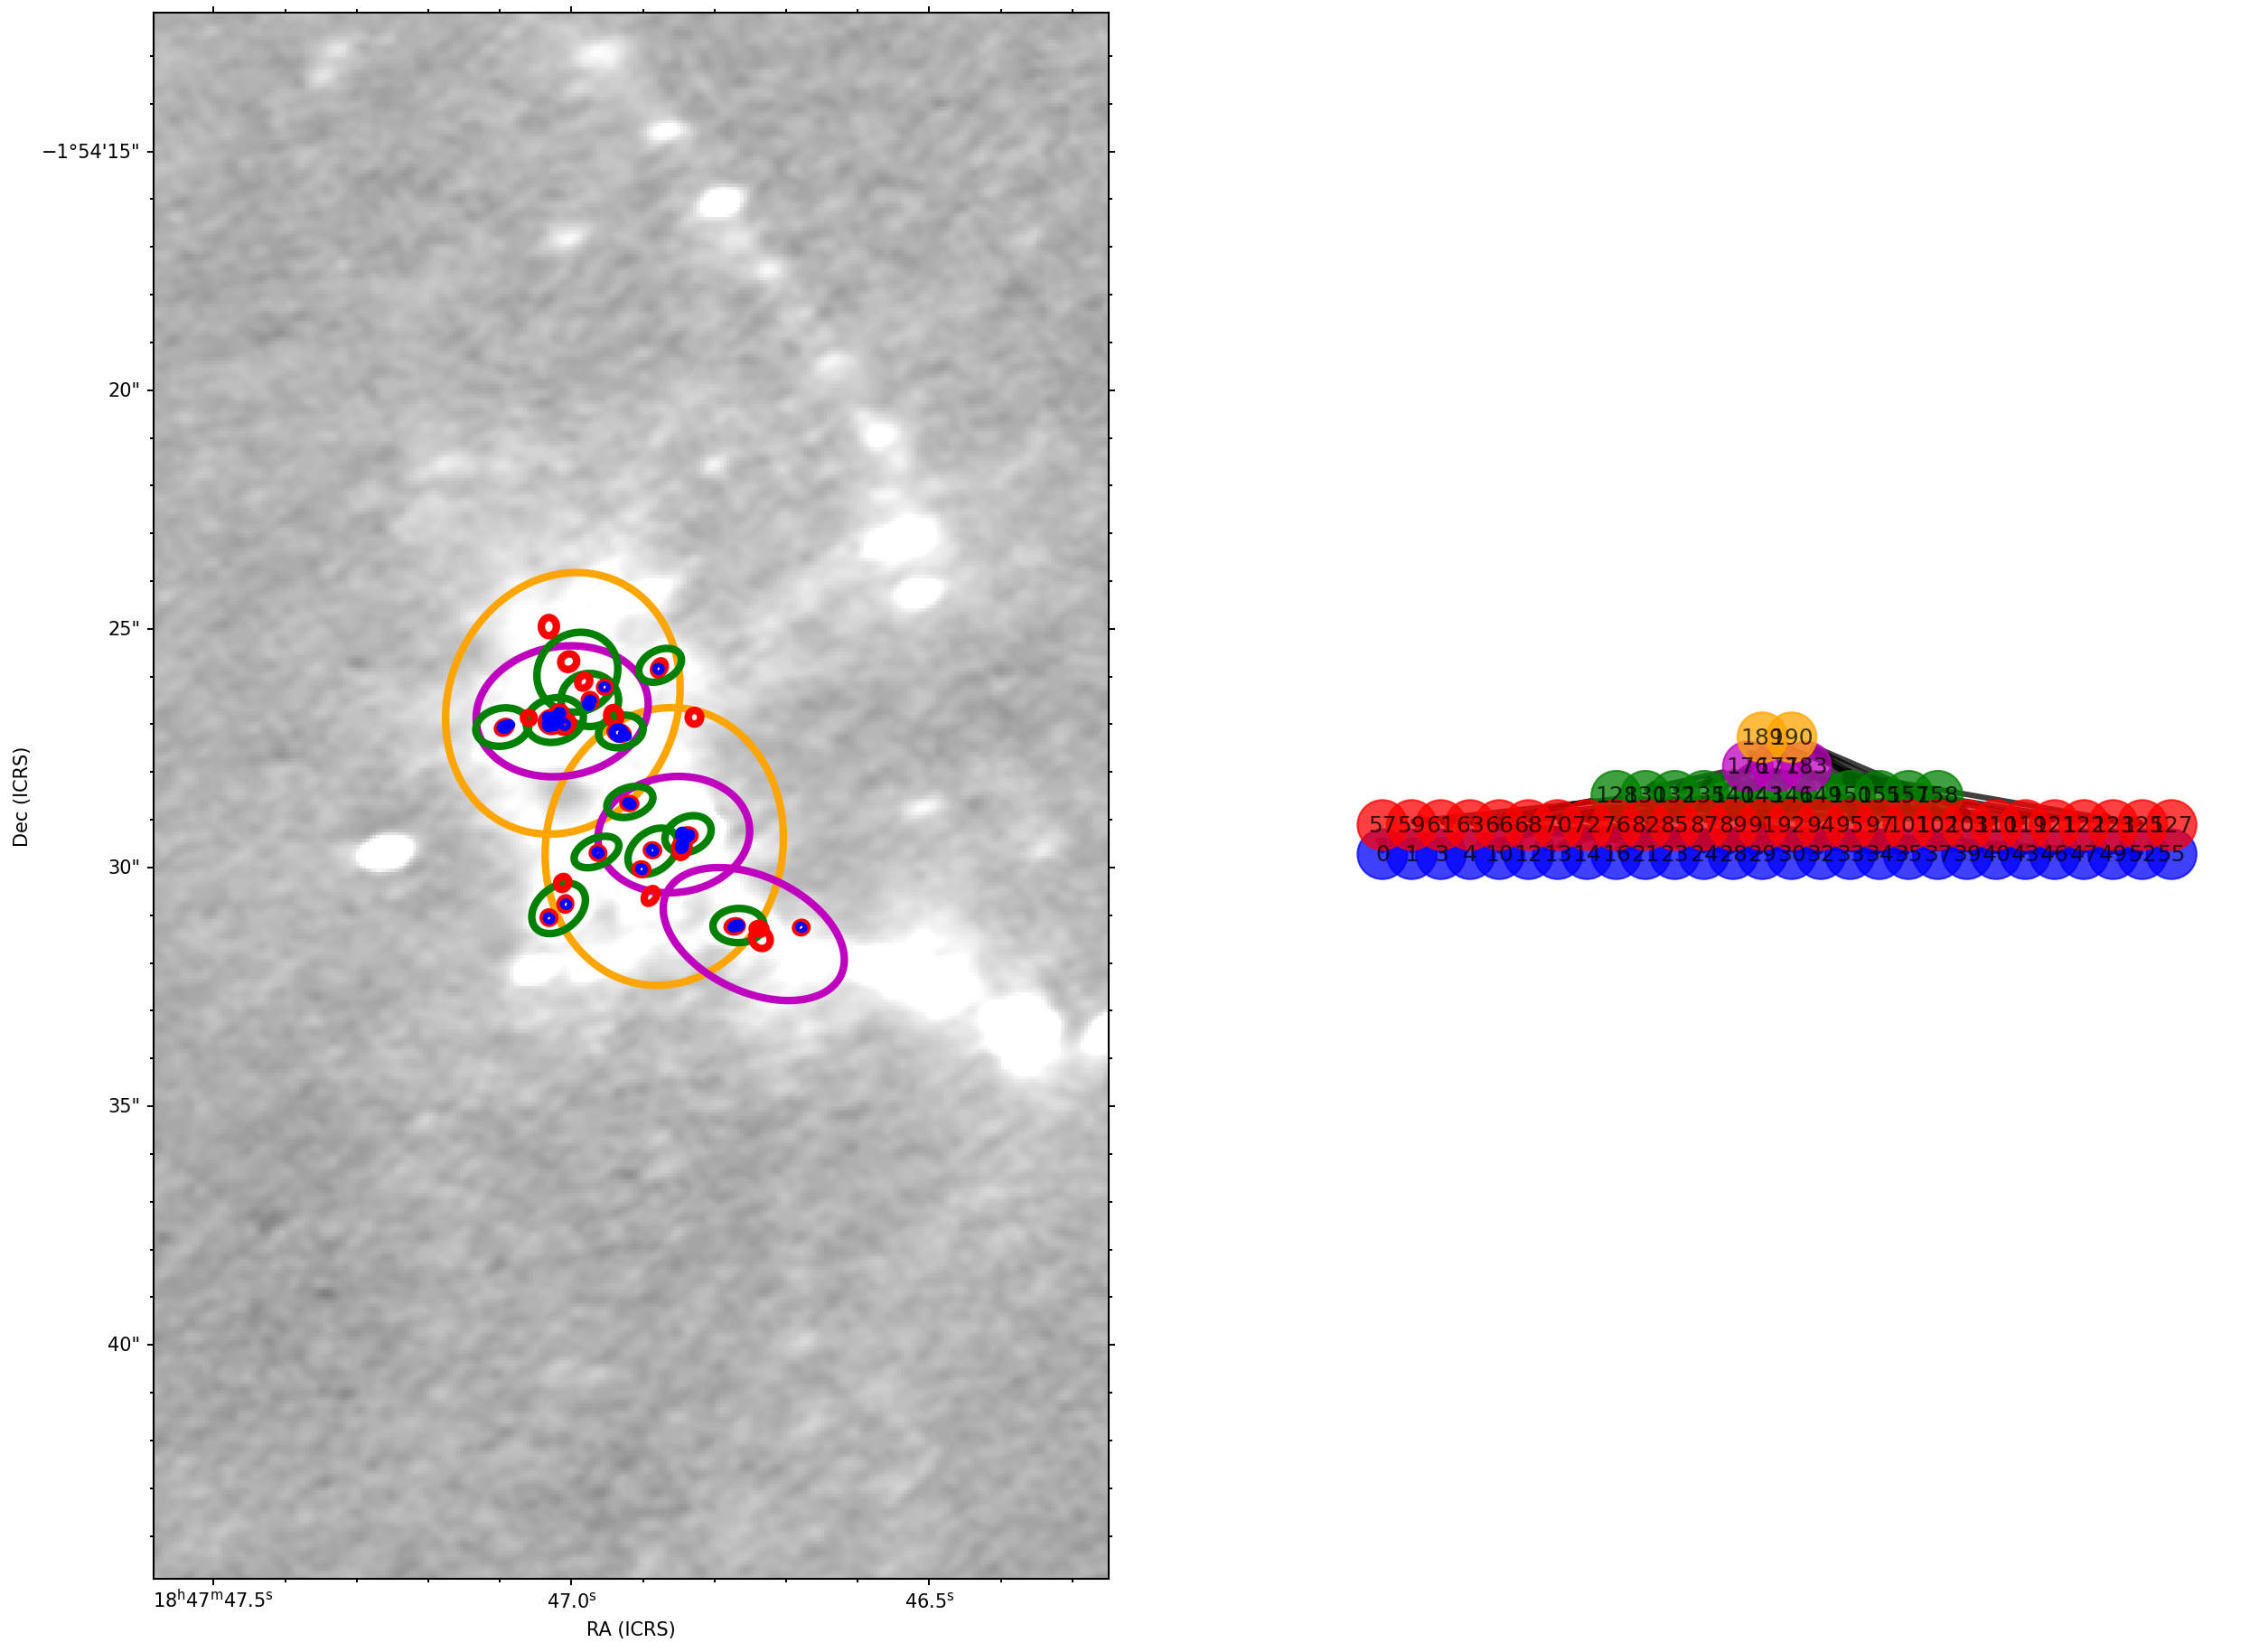

In [80]:
image = dataset._data['2400AU'].fits_img
fig = network.structures[0].plot(image)

In [68]:
plotter.InspectNetwork(network)

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


INFO: Auto-setting vmin to -5.355e-04 [aplpy.core]
INFO: Auto-setting vmax to  5.838e-04 [aplpy.core]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


<Figure size 2400x2400 with 0 Axes>

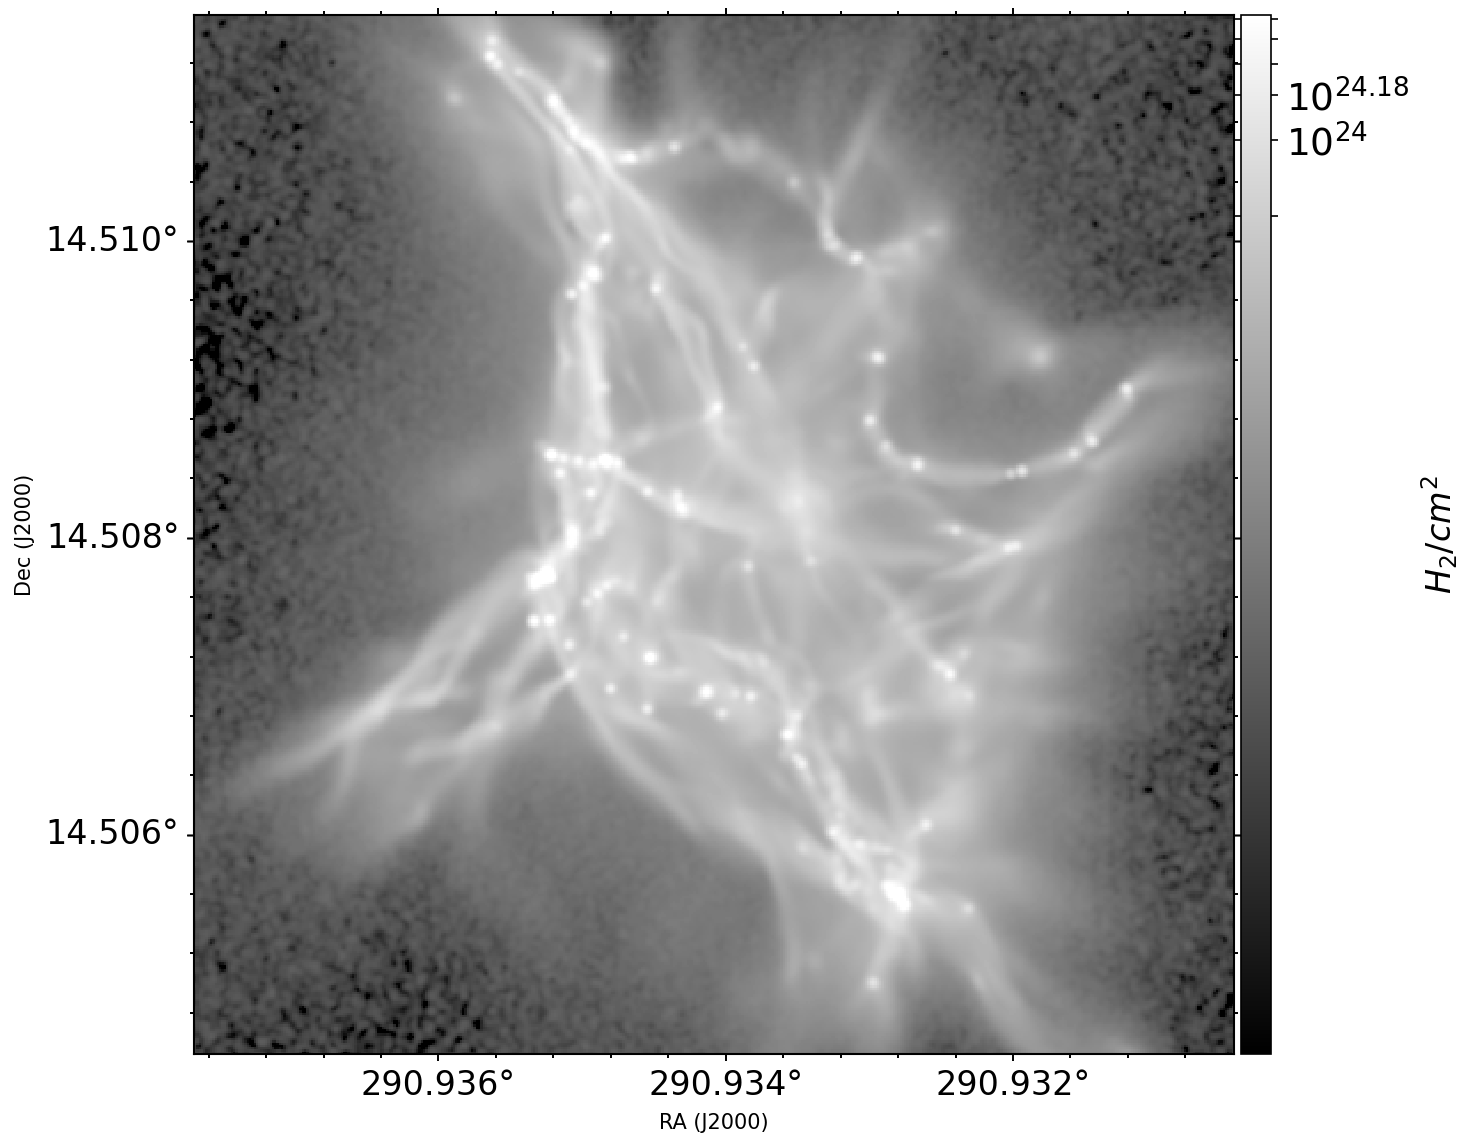

In [ ]:
import aplpy
from astropy.io import fits
from astropy.wcs import WCS
from shapely.affinity import rotate

####### Figures Definition
FIGURE = plt.figure(figsize=(16, 16))


colors = ["m", "g", "b", "r", "c"]

hdu = fits.open('benchmark2AU/fits/column_density_01500_z.+.noise.mul1e23.r900au.bor-4650.rs333au.fits')

img = hdu[0].data
hdr = hdu[0].header


vmin = np.nanpercentile(np.where(img>0, img, np.nan), 0.1)
vmax = np.nanpercentile(np.where(img>0, img, np.nan), 99.9)

new_fits = fits.PrimaryHDU(data=img, header=hdr)


fig = aplpy.FITSFigure(new_fits)

#fig.show_colorscale(cmap='Greys', vmin=vmin, vmax=vmax, stretch='log') 
fig.show_grayscale(vmin=vmin, vmax=vmax, stretch='log') 

fig.add_colorbar()
fig.colorbar.set_font(size=12)
fig.colorbar.set_axis_label_font(size=16)

ticks = 10**np.arange(np.log10(vmin), np.log10(vmax))
fig.colorbar.show(log_format=True)
fig.colorbar.set_axis_label_text("$H_2 / cm^2$")
fig.colorbar.set_font(size=18)


fig.tick_labels.set_xformat('dd.ddd')
fig.tick_labels.set_yformat('dd.ddd')
fig.tick_labels.set_font(size=16)


# structures
modes = ['ISOLATED', 'LINEAR', 'HIERARCHICAL']
colors = ['brown',  'orange', 'deepskyblue'] #= azure
hatches = ['----', '||||||', '///////']
alphas = [0.2, 0.2, 0.2]



for mode, color, hatch, alpha in zip(modes, colors, hatches, alphas):
    polygons = structure_table["polygon"][structure_table["mode"] == mode]
    comp = structure_table["component"][structure_table["mode"] == mode]
    PTS = []
    for i, poly in enumerate(polygons):
        node = sorted(comp.values[i].nodes)[-1]
        x, y = poly.exterior.xy
        PTS.append(np.reshape(np.ravel([x, y]), (len(x), 2), order='F'))

    fig.show_polygons(PTS, facecolor=color, edgecolor="none", alpha=alpha)
    fig.show_polygons(PTS, facecolor="none", edgecolor=color, hatch=hatch)
    fig.show_polygons(PTS, facecolor="none", edgecolor=color, alpha=0.5)


#fig.scalebar.show()  # length in degrees
plt.savefig('Struct_Repartition.pdf')

# Fractalité et N vs R

mean prod. y axis = [np.float64(4.0), np.float64(3.875), np.float64(1.7777777777777777), np.float64(1.0), np.float64(1.0)]


Text(0, 0.5, '$<N_{tot}/N_{tot}^0>$')

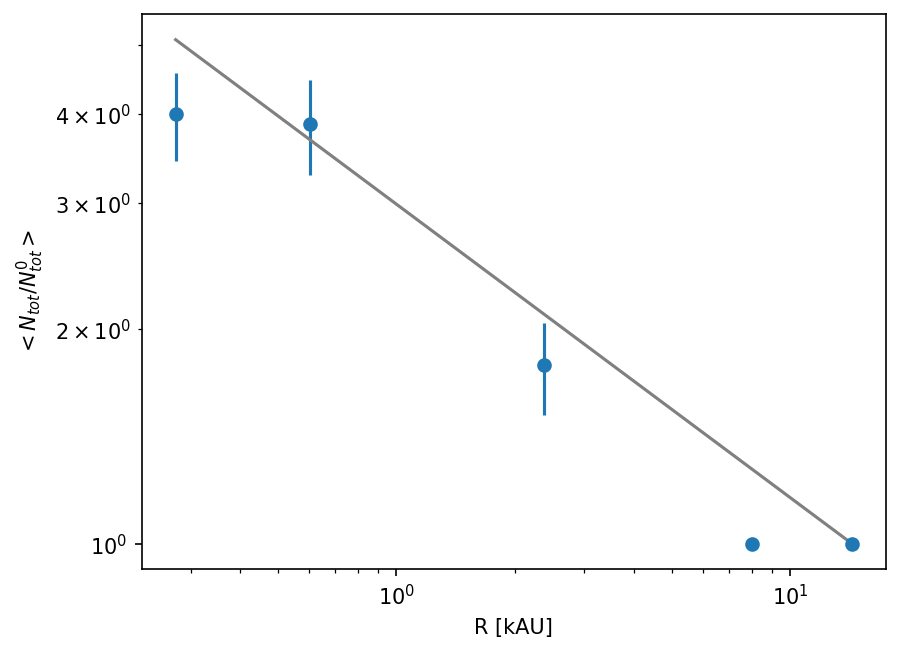

In [70]:
distance = network.data[-1].distance
x, meany, stdy = plotter.getFragCurve(network, distance, mode = "HIERARCHICAL")

print("mean prod. y axis =", meany)

fig, ax = plt.subplots()

x_kau = x / 1000
ax.errorbar(x_kau, meany, stdy, np.zeros_like(x), "o")

fractality = np.mean(1.33)
fractality_arr = np.ones_like(x) * fractality
exponent = -(np.log(fractality_arr)/np.log(2))

ax.plot(x_kau, (x / max(x))**exponent, "-", color="grey")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("R [kAU]")
ax.set_ylabel("$<N_{tot}/N_{tot}^0>$")

# Uncertainties with virtual nodes

In [71]:
nb_node = []

fractal = []
suspicious = []
fractal_160conv = []
fractal_geom = []

fractal_corr = []
missed_corr = []

n_core_lin = 0
n_core_iso = 0
n_core_hier = 0
idx = 0
number_h = 0
number_l = 0
number_i = 0
number_iso43 = 0
for s in network.structures:
    #print(s.component.in_degree)
    if s.mode.name == "HIERARCHICAL":# or s.mode.name == "LINEAR":
        if idx not in suspicious:
            fractal_corr.append(s.fractality)
            missed_corr.append(s.percmissed)
            number_h += 1
            n_core_hier += len(s.component)
        fractal.append(s.fractality)
        idx += 1
        nb_node.append(len(s.component))
    if s.mode.name == "LINEAR":
        number_l += 1
        n_core_lin += len(s.component)
    if s.mode.name == "ISOLATED":
        number_iso43 += 1
        number_i += 1
        n_core_iso += len(s.component)

print("number of hierarchical cores = ", n_core_hier)
print("number of linear cores = ", n_core_lin)
print("number of isolated cores = ", n_core_iso)
print("number of hierarchical structures = ", number_h)
print("number of isolated structures with scale 0.43 = ", number_iso43)
print("number of linear structures = ", number_l)
print("number of isolated structures = ", number_i) 
print("------------------------------------------------\n")

#print(fractal)
print(f"mean = {np.mean(fractal):.2f} +/- {np.std(fractal):.2f}")
print(f"median = {np.median(fractal):.2f}")

fractality_corr_carences = ( np.median(fractal_corr) * (1+0.2) + np.median(fractal))/2
dfractality_corr_carences = fractality_corr_carences - np.median(fractal)

print(f"carences corr = {fractality_corr_carences:.2f}")

phi2D = np.log(fractality_corr_carences) / np.log(2)
dphi2D = dfractality_corr_carences / fractality_corr_carences

print(f"phi2D = {phi2D:.2f} +/- {dphi2D:.2f}")

f = -0.3
projection_error = -0.3
dprojection_error = 0.05

d1 = (dphi2D/(1 + projection_error))**2
d2 = (phi2D / (1 + projection_error)**2 * dprojection_error) **2

phi3D, dphi3D = phi2D / (1 + f), np.sqrt(d1 + d2)

print(f"phi3D = {phi3D:.2f} +/- {dphi3D:.2f}")
print(f"F_3D = {np.exp(phi3D*np.log(2)):.2f}")
print(f"Number of node in the Hierarchical structures come from {np.min(nb_node)} to {np.max(nb_node)}")

number of hierarchical cores =  139
number of linear cores =  46
number of isolated cores =  7
number of hierarchical structures =  9
number of isolated structures with scale 0.43 =  7
number of linear structures =  18
number of isolated structures =  7
------------------------------------------------

mean = 1.36 +/- 0.12
median = 1.39
carences corr = 1.52
phi2D = 0.61 +/- 0.09
phi3D = 0.87 +/- 0.14
F_3D = 1.83
Number of node in the Hierarchical structures come from 3 to 73


In [72]:
virtual = utility.virtualNodes(network.network, network.levels)

In [73]:
network_virtualfill = analyse.Network(analyse.DataSet(network.data), min_overlap=network.min_overlap, graph=virtual)

utility.fractality(network_virtualfill.network)

clumps = utility.toDataFrame(network_virtualfill.network)

network_virtualfill.extractStructures()
structure_table_virtual = network_virtualfill.getStructuresTable()

median with virtual nodes = 1.4191
median without virtual nodes = 1.3852


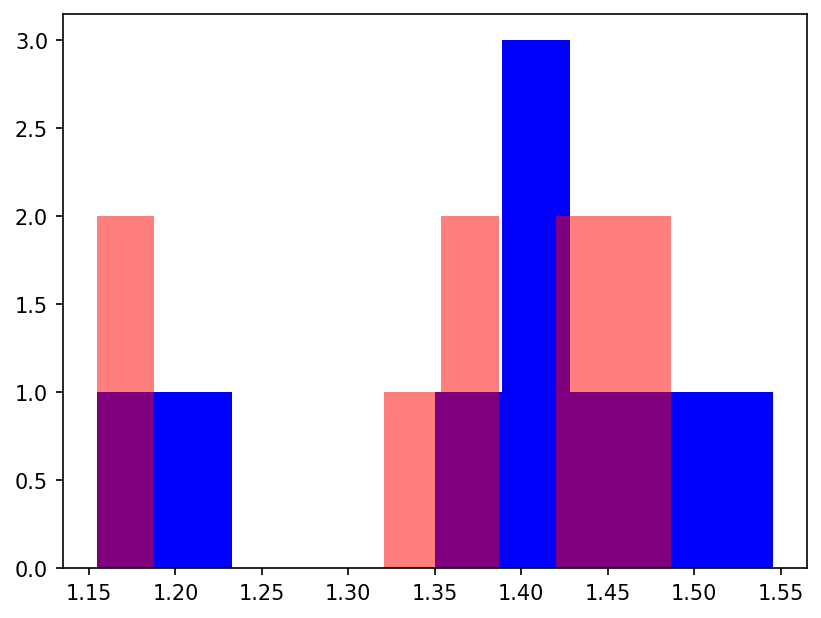

In [74]:
plt.hist(structure_table_virtual['fractality'][structure_table_virtual['mode'] == "HIERARCHICAL"], color="b")
plt.hist(structure_table['fractality'][structure_table['mode'] == "HIERARCHICAL"], color="r", alpha=0.5)

print(f"median with virtual nodes = {np.median(structure_table_virtual['fractality'][structure_table_virtual['mode'] == "HIERARCHICAL"]):.4f}")
print(f"median without virtual nodes = {np.median(structure_table['fractality'][structure_table['mode'] == "HIERARCHICAL"]):.4f}")

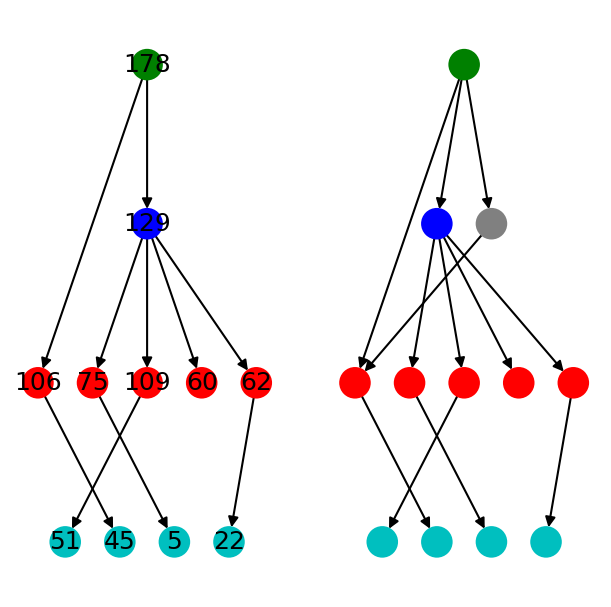

In [75]:
import networkx as nx
# Check virtuals

hierarchical_structures = structure_table["component"][structure_table["mode"] == "HIERARCHICAL"]
hierarchical_structures_virtuals = structure_table_virtual["component"][structure_table_virtual["mode"] == "HIERARCHICAL"]

idx = 2
struct = hierarchical_structures.array[idx]
struct_virtual = hierarchical_structures_virtuals.array[idx]

colors = ["m", "g", "b", "r", "c"][::-1]
scales = network.levels
colors = {str(scale):color for color, scale in zip(colors, scales)}

color = []
for _, b in struct.nodes("_beam"):
    if b != 2.:
        color.append(colors[str(b)])
    else:
        color.append("grey")

color_virtual = []
for node, b in struct_virtual.nodes("_beam"):
    if b != 2. and struct_virtual.nodes[node]["_Kind"].name != "VIRTUAL":
        color_virtual.append(colors[str(b)])
    elif b ==2:
        color_virtual.append("k")
    else:
        color_virtual.append("grey")
                
figure, axs = plt.subplots(ncols=2, figsize=(5, 5))

# without virtuals
pos = nx.multipartite_layout(struct, subset_key="_level", align="horizontal")
nx.draw(struct, pos, ax=axs[0], node_color=color, node_size=200, with_labels=True)

# with virtuals
pos = nx.multipartite_layout(struct_virtual, subset_key="_level", align="horizontal")
nx.draw(struct_virtual, pos, ax=axs[1], node_color=color_virtual, node_size=200, with_labels=False)

In [76]:
def fragmentation_rate2D(fractality, uncertainty):
    return np.log(fractality)/np.log(2), uncertainty/fractality/np.log(2)

for structure_real, structure_hole in zip(network.structures, network_virtualfill.structures):

    fractality = (structure_real.fractality + structure_hole.fractality)/2
    uncertainty = abs(structure_real.fractality - structure_hole.fractality)/2
    
    phi, dphi = fragmentation_rate2D(fractality, uncertainty)

    structure_real.fragmentation_rate = phi, dphi
    

In [77]:
for s in network.structures:
    if s.mode.name == "HIERARCHICAL":
        print(s.fragmentation_rate)

(np.float64(0.600406335500393), np.float64(0.02798416217368193))
(np.float64(0.5365577781086627), np.float64(0.0))
(np.float64(0.4875978744710091), np.float64(0.01744324936647624))
(np.float64(0.4332322587048964), np.float64(0.02554145105945121))
(np.float64(0.4875978744710091), np.float64(0.01744324936647624))
(np.float64(0.24295722420661614), np.float64(0.03546043085841854))
(np.float64(0.20705372177761275), np.float64(0.0))
(np.float64(0.5084315398513061), np.float64(0.0))
(np.float64(0.5702410573587646), np.float64(0.0))


# Mass transfer

In [78]:
from  analysis import multiscale_structures

hierachical_nodes = []
for s in structure_table['component'][structure_table['mode'] == "HIERARCHICAL"]:
    hierachical_nodes.extend(list(s))
def find_structure_with_node(node, network):
    for i, structure in enumerate(network.structures):
        if node in structure.component:
            return i
    return None


def rescaling(Mfrom, Mto, Scaleid_from, Scaleid_to):
    coef = 1 / ( np.log(Scaleid_from/Scaleid_to) / np.log(2) ) 
    Matt = ( (Mto/Mfrom)**coef ) * Mfrom
    return Matt 

def InjectionMassRate(Ri, Rii, Mi, Mii):
    lnMtot = np.log(Mii) - np.log(Mi)
    lnR = np.log(Rii) - np.log(Ri)
    return -lnMtot/lnR  


Q = {}

for i in range(len(network.structures)):
    if network.structures[i].mode.name == "HIERARCHICAL":
        L = np.array(list(network.structures[i].component.in_edges.keys()), dtype = int)
        for j in L:
            parent = j[0]
            child = j[1]
            try:
                Q[parent].append([child, clumps['_beam'][child] , clumps['_M'][child], clumps['_beam'][parent] ,clumps['_M'][parent] ])
            except KeyError:
                Q[parent] = [[child, clumps['_beam'][child] , clumps['_M'][child], clumps['_beam'][parent] ,clumps['_M'][parent] ]]


mass_transfer_efficiency = []
mass_partition = []
dominant_child_mass = []

for key, value in Q.items():
    total_child_flux = 0
    for i in value:
        total_child_flux += rescaling(i[4], i[2], i[3], i[1])
    child_sorted = sorted(value, key=lambda x: rescaling(x[4], x[2], x[3], x[1]), reverse=True)
    mass_transfer_efficiency.append(total_child_flux / child_sorted[0][4] * 100)
    if len(child_sorted) >= 2:
        dominant_child_mass.append(rescaling(child_sorted[0][4], child_sorted[0][2], child_sorted[0][3], child_sorted[0][1]) / child_sorted[0][4] * 100)
    
        mass_partition.append(rescaling(child_sorted[0][4], child_sorted[0][2], child_sorted[0][3], child_sorted[0][1]) / rescaling(child_sorted[1][4], child_sorted[1][2], child_sorted[1][3], child_sorted[1][1]))

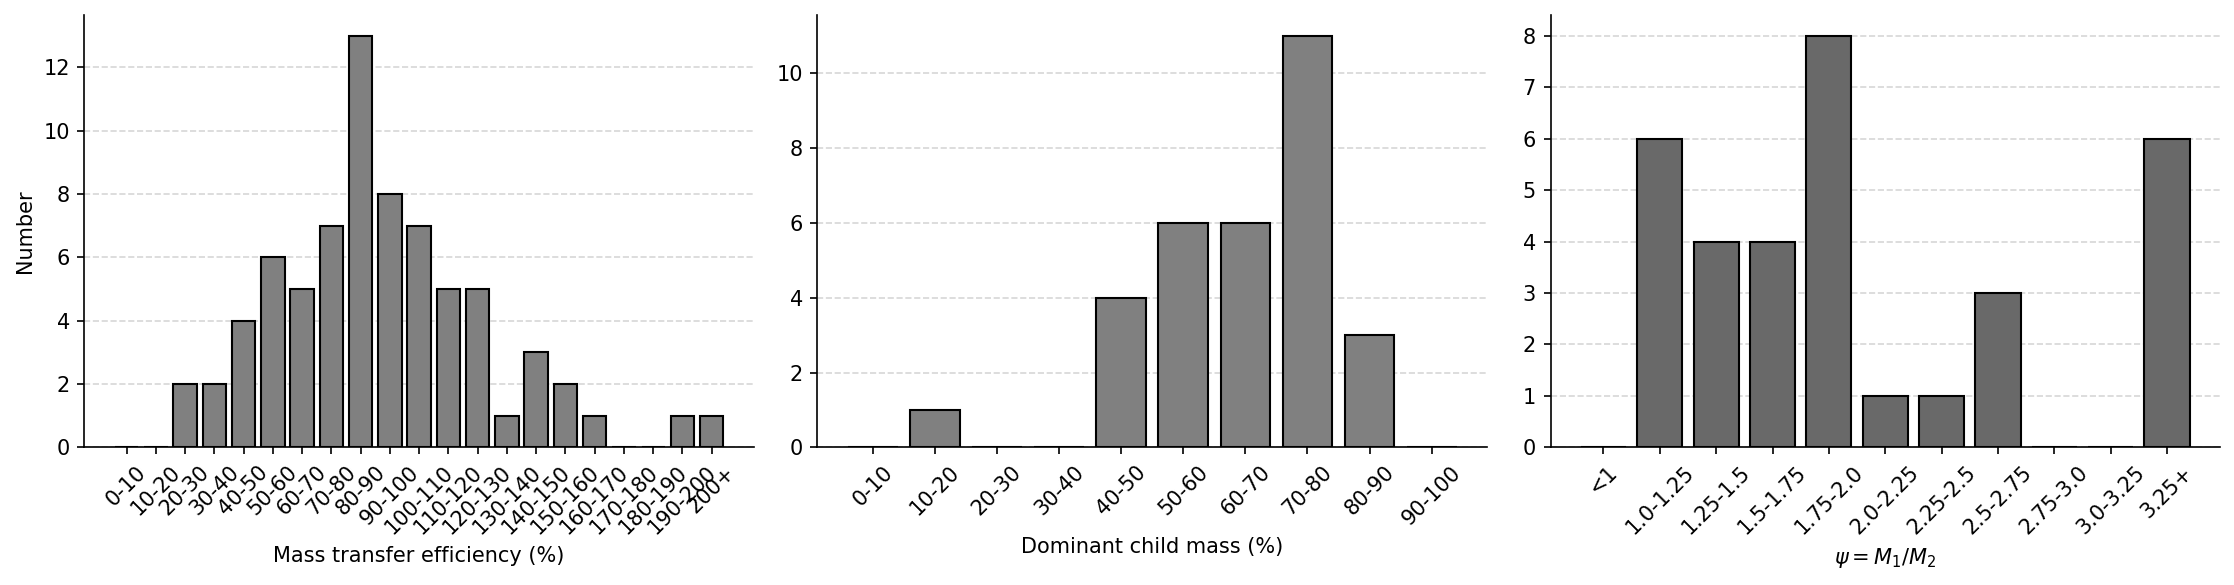

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)



values = np.array(mass_transfer_efficiency)


max_val = 200

bins = np.r_[np.arange(0, max_val + 10, 10), np.inf]  # 0-10, ..., 90-100, 100+
counts, _ = np.histogram(values, bins=bins)
labels = [f"{i}-{i+10}" for i in range(0, int(max_val), 10)] + [f"{int(max_val)}+"]




axes[0].bar(labels,counts,color='gray',edgecolor='black',width=0.8)
axes[0].set_xlabel('Mass transfer efficiency (%)')
axes[0].set_ylabel('Number')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[0].set_axisbelow(True)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

values = np.array(dominant_child_mass)

bins = np.r_[np.arange(0, 110, 10)]  # 0-10, ..., 90-100, 100+
counts, _ = np.histogram(values, bins=bins)
labels = [f"{i}-{i+10}" for i in range(0, 100, 10)]

axes[1].bar(labels, counts, color='gray', edgecolor='black', width=0.8)
axes[1].set_xlabel('Dominant child mass (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

values = np.array(mass_partition)

bins = np.r_[-np.inf, np.arange(1, 3.5, 0.25), np.inf]  # 0-10, ..., 90-100, 100+
counts, _ = np.histogram(values, bins=bins)
labels = ['<1'] + [f"{i}-{i+0.25}" for i in np.arange(1, 3.25, 0.25)] + ["3.25+"]

axes[2].bar(labels, counts, color='dimgray', edgecolor='black', width=0.8)
axes[2].set_xlabel(r'$\psi = M_1 / M_2$')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[2].set_axisbelow(True)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('Mass_statistics_AA.pdf', bbox_inches='tight')
plt.show()